# Prepare data for students for the Temperature chapter.

Note that, below, GMST=global mean surface temperature.

Overview: read data/ scenarios from the CESM CMIP6 runs:
RCP26
RCP45
RCP85
PIcontrol (pre-industrial control).
And observations of the GISS (Goddard Institute of Space Science) GMST from
https://data.giss.nasa.gov/gistemp/ (documentation)
https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv (data)

Tasks: Calculate the following quantities and produce the following output
files:

(1) Time series:
RCP26_GMST_annual_anomaly_timeseries.npy     (years 2005-2100)
RCP45_GMST_annual_anomaly_timeseries.npy     (years 2005-2100)
RCP85_GMST_annual_anomaly_timeseries.npy     (years 2005-2100)
PIcontrol_GMST_annual_anomaly_timeseries.npy (years 0-200)
OBS_GISS_GMST_annual_anomaly_timeseries.npy  (years 1850 to today)

(2) 2D (lon,lat) maps:
RCP85_SAT_map_first_5yr.npy (years 2005-2010)
RCP85_SAT_map_last_5yr.npy  (years 2095-2100)
and the corresponding two 1D (lat, lon) axes:
RCP85_SAT_map_lon.npy
RCP85_SAT_map_lat.npy

(3) Atmospheric temperature as a function of height and latitude,
average zonally and over 5 years as above:
RCP85_zonally_avg_T_2010.npy
RCP85_zonally_avg_T_2100.npy
and the corresponding height level (km) and latitude axes:
RCP85_zonally_avg_T_height.npy
RCP85_zonally_avg_T_lat.npy


In [1]:
"""
Full CMIP6 Temperature Analysis Pipeline
- Preprocess tas and ta (monthly if needed)
- Compute GMST annual anomalies (CMIP6 + GISS)
- Compute 2D SAT maps (first/last 5 years)
- Compute zonal-mean atmospheric temperature (first/last 5 years)
"""

import numpy as np
import pandas as pd
import xarray as xr
import intake
import os

xr.set_options(keep_attrs=True)

# =====================================================
# CONFIG
# =====================================================
OUT_DIR = "./Output/to-pickle"
CATALOG_URL = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
SOURCE_ID = "CESM2"
TABLE_ID = "Amon"
VARIABLES = ["tas", "ta"]

cmip6_labels = ["RCP26", "RCP45", "RCP85", "PIcontrol"]
cmip6_experiments = {
    "RCP26": "ssp126",
    "RCP45": "ssp245",
    "RCP85": "ssp585",
    "PIcontrol": "piControl"
}

ssp_start = 2015
ssp_end   = 2100

# =====================================================
# HELPER FUNCTIONS
# =====================================================
def preprocess_da(ds, var):
    """Preprocess CMIP6 Amon DataArray from Dataset"""
    ds = xr.decode_cf(ds)
    da = ds[var].squeeze(drop=True)

    # select first ensemble/init
    for dim in ["member_id", "dcpp_init_year"]:
        if dim in da.dims:
            da = da.isel({dim: 0})

    # normalize longitude
    if "lon" in da.coords:
        da = da.assign_coords(lon=(da.lon % 360))

    # convert units if needed
    sample = float(da.isel(time=0).mean().compute())
    if sample < 100:
        da = da + 273.15
        da.attrs["units"] = "K"

    return da

def compute_global_mean_annual(da):
    """Compute global annual mean temperature"""
    weights = np.cos(np.deg2rad(da.lat))
    gmst_monthly = da.weighted(weights).mean(dim=("lat", "lon"))
    gmst_annual = gmst_monthly.groupby("time.year").mean()
    return gmst_annual.year.values, gmst_annual.values


def compute_anomaly(years, values, baseline_years):
    mask = (years >= baseline_years[0]) & (years <= baseline_years[1])
    return values - values[mask].mean()


# =====================================================
# CMIP6 DATA LOADER
# =====================================================
def load_cmip6_data(col):
    """Load and preprocess CMIP6 data"""
    cmip6_data = {}

    for label in cmip6_labels:
        print(f"\nLoading {label}...")
        exp = cmip6_experiments[label]

        for var in VARIABLES:
            
            # We need surface temperature for all listed experiments, 
            # and atmospheric temperature only for RCP85:
            if var == "tas" or (var=="ta" and "85" in label):
                subset = col.search(
                    source_id=SOURCE_ID,
                    experiment_id=exp,
                    table_id=TABLE_ID,
                    variable_id=var
                )
    
                dsdict = subset.to_dataset_dict(zarr_kwargs={"consolidated": True})
                if len(dsdict) == 0:
                    raise RuntimeError(f"No Amon data found for {label} {var}")
                key = list(dsdict.keys())[0]
                ds = dsdict[key]
    
                da = preprocess_da(ds, var)
    
                if "ssp" in exp:
                    da = da.sel(time=slice(f"{ssp_start}-01-01", None))
    
                cmip6_data[f"{label}_{var}"] = da
                print(f"  {var}: shape {da.shape}, units: {da.attrs.get('units','')}")

    return cmip6_data

# =====================================================
# TASKS
# =====================================================
def compute_gmst_anomalies(cmip6_data, giss_last_5_years, giss_Tavg_last_5_years):
    """Compute GMST annual anomalies"""
    print("\nComputing GMST annual anomalies...")

    anomalies={}
    cmip_avg = 0.0
    for label in cmip6_labels:
        da = cmip6_data[f"{label}_tas"]
        years, gmst = compute_global_mean_annual(da)

        # set baseline depending on if this is RCP or PIcontrol:
        baseline = (years[0], years[9]) if "RCP" in label else (years[0], years[-1])

        gmst_anom = compute_anomaly(years, gmst, baseline)

        anomalies[f"{label}"] = (years, gmst_anom)

        # Calculate a shift to the cmip anomaly so that last 5 years  
        # of giss are like the corresponding five years of the cmip scenarios:
        if "RCP" in label:
            cmip_avg = cmip_avg \
              + np.mean(gmst_anom[np.isin(years,giss_last_5_years)])
    
    cmip_avg = cmip_avg/3
    offset=giss_Tavg_last_5_years-cmip_avg
    
    for label in cmip6_labels:
        years, gmst_anom = anomalies[f"{label}"]
        if "control" not in label:
            # add offset and save for students
            np.save(
                f"{OUT_DIR}/{label}_GMST_annual_anomaly_timeseries.npy",
                np.column_stack((years, gmst_anom+offset))
            )
        else:
            # For control, save temporary file. Some additional processing needs  
            # to be done below before saving final copy for students:
            np.save(
                f"Output/{label}_GMST_annual_anomaly_timeseries_temporary.npy",
                np.column_stack((years, gmst_anom))
            )

            
        print(f"{label}: {years[0]}–{years[-1]}, baseline {baseline[0]}–{baseline[1]}")


def process_giss_observations():
    """Process GISS observations"""
    print("\nProcessing GISS observations...")

    url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"
    df = pd.read_csv(url, skiprows=1).replace("***", np.nan)
    df = df.rename(columns={"Year": "year"})

    months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    df[months] = df[months].astype(float)

    years = df["year"].values
    gmst_annual = df[months].mean(axis=1, skipna=True).values

    gmst_annual = gmst_annual + 273.15

    gmst_anom = compute_anomaly(years, gmst_annual, (1951, 1980))

    np.save(
        f"{OUT_DIR}/OBS_GISS_GMST_annual_anomaly_timeseries.npy",
        np.column_stack((years, gmst_anom))
    )
    
    giss_Tavg_last_5_years=np.mean(gmst_anom[years>=years[-5]])
    giss_last_5_years=years[years>=years[-5]]
    
    return giss_last_5_years, giss_Tavg_last_5_years


def compute_2d_sat_maps(cmip6_data):
    """Compute 2D SAT maps (RCP85)"""
    print("\nComputing 2D SAT maps (RCP85)...")

    da = cmip6_data["RCP85_tas"]
    da_first5 = da.sel(time=slice("2015-01-01", "2019-12-31")).mean("time")
    da_last5  = da.sel(time=slice("2096-01-01", "2100-12-31")).mean("time")
    
    np.save(f"{OUT_DIR}/RCP85_SAT_map_first_5yr.npy", da_first5.values)
    np.save(f"{OUT_DIR}/RCP85_SAT_map_last_5yr.npy", da_last5.values)
    np.save(f"{OUT_DIR}/RCP85_SAT_map_lat.npy", da.lat.values)
    np.save(f"{OUT_DIR}/RCP85_SAT_map_lon.npy", da.lon.values)


def compute_zonal_mean_temperature(cmip6_data):
    """Compute zonal-mean atmospheric temperature (RCP85)"""
    print("\nComputing zonal-mean atmospheric temperature (RCP85)...")

    da = cmip6_data["RCP85_ta"]
    da_first5 = da.sel(time=slice("2015-01-01", "2019-12-31")).mean("time")
    da_last5  = da.sel(time=slice("2096-01-01", "2100-12-31")).mean("time")

    zonal_first5 = da_first5.mean("lon")
    zonal_last5  = da_last5.mean("lon")

    R=287      # gas constant J/kg/K\n",
    g=9.8
    Tbar=260
    plev=da.plev.values
    height=-np.log(plev/100000)*R*Tbar/g/1000

    np.save(f"{OUT_DIR}/RCP85_zonally_avg_T_2010.npy", zonal_first5.values)
    np.save(f"{OUT_DIR}/RCP85_zonally_avg_T_2100.npy", zonal_last5.values)
    np.save(f"{OUT_DIR}/RCP85_zonally_avg_T_lat.npy", da.lat.values)
    np.save(f"{OUT_DIR}/RCP85_zonally_avg_T_height.npy",height)
    
# =====================================================
# MAIN
# =====================================================

os.makedirs(OUT_DIR, exist_ok=True)

print("Opening CMIP6 catalog...")
col = intake.open_esm_datastore(CATALOG_URL)

cmip6_data = load_cmip6_data(col)
giss_last_5_years, giss_Tavg_last_5_years = process_giss_observations()
compute_gmst_anomalies(cmip6_data, giss_last_5_years, giss_Tavg_last_5_years)
compute_2d_sat_maps(cmip6_data)
compute_zonal_mean_temperature(cmip6_data)

unit = "K"
print(f"\nAll tasks completed successfully.")

Opening CMIP6 catalog...



Loading RCP26...



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  tas: shape (1032, 192, 288), units: K

Loading RCP45...



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


...

  tas: shape (14400, 192, 288), units: K

Processing GISS observations...



Computing GMST annual anomalies...


RCP26: 2015–2100, baseline 1–1200
RCP45: 2015–2100, baseline 1–1200
RCP85: 2015–2100, baseline 1–1200
PIcontrol: 1–1200, baseline 1–1200

Computing 2D SAT maps (RCP85)...



Computing zonal-mean atmospheric temperature (RCP85)...



All tasks completed successfully.


Verifying saved .npy files...

OBS_GISS_GMST_annual_anomaly_timeseries.npy | shape: (146, 2) | min: -0.49, max: 2025.00
PIcontrol_GMST_annual_anomaly_timeseries.npy | shape: (101, 2) | min: -0.31, max: 100.00
RCP26_GMST_annual_anomaly_timeseries.npy | shape: (86, 2) | min: 0.83, max: 2100.00
RCP45_GMST_annual_anomaly_timeseries.npy | shape: (86, 2) | min: 0.69, max: 2100.00
RCP85_GMST_annual_anomaly_timeseries.npy | shape: (86, 2) | min: 0.63, max: 2100.00
RCP85_SAT_map_first_5yr.npy | shape: (192, 288) | min: 221.35, max: 305.33
RCP85_SAT_map_last_5yr.npy | shape: (192, 288) | min: 227.76, max: 311.86
RCP85_SAT_map_lat.npy | shape: (192,) | min: -90.00, max: 90.00
RCP85_SAT_map_lon.npy | shape: (288,) | min: 0.00, max: 358.75
RCP85_zonally_avg_T_2010.npy | shape: (19, 192) | min: 193.53, max: 299.94
RCP85_zonally_avg_T_2100.npy | shape: (19, 192) | min: 193.25, max: 304.35
RCP85_zonally_avg_T_height.npy | shape: (19,) | min: -0.00, max: 52.60
RCP85_zonally_avg_T_lat.npy | shape: (192,

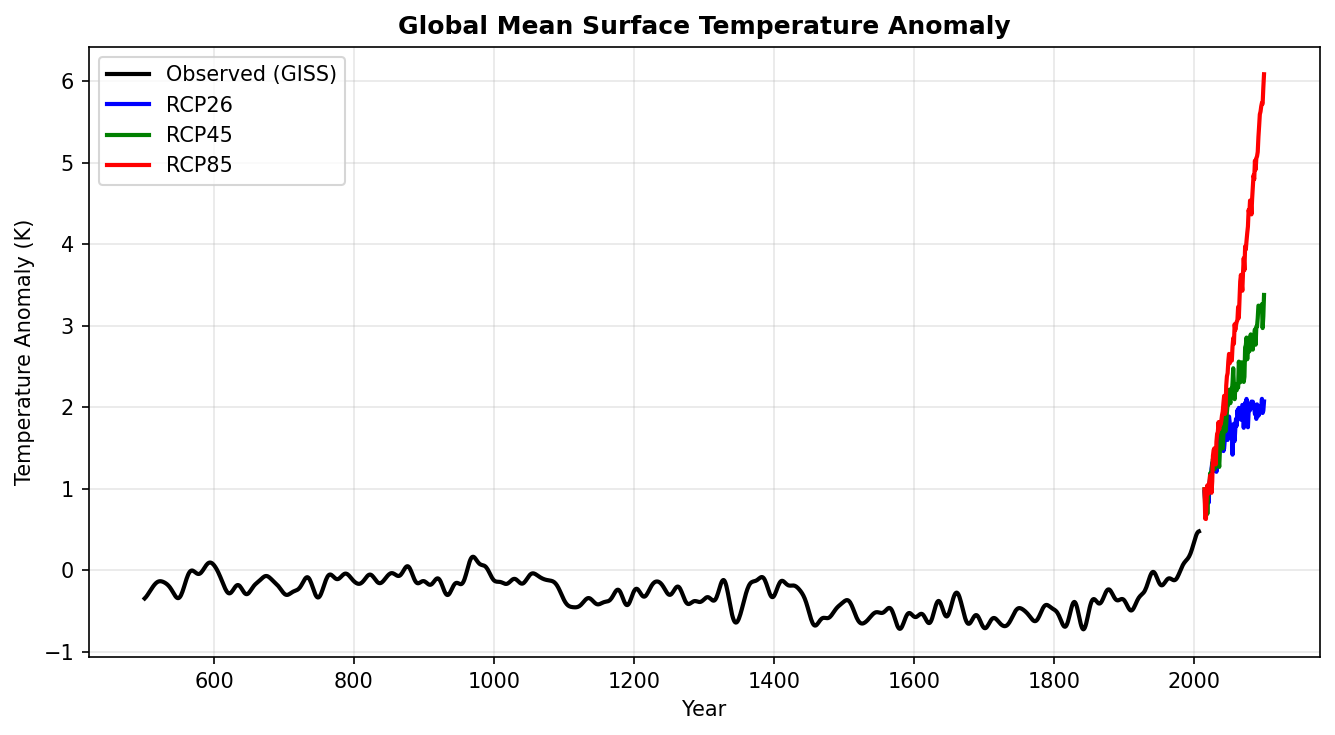

Plotting RCP8.5 SAT maps...


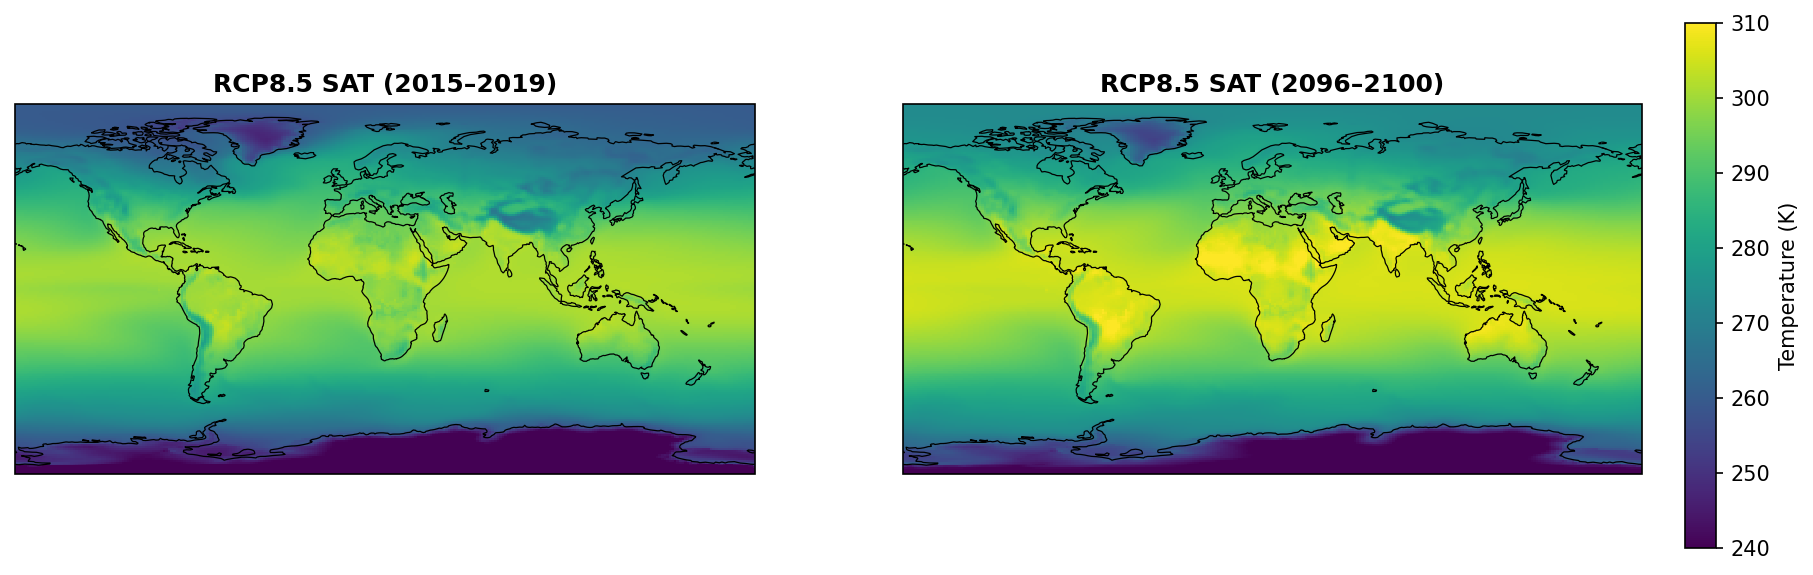

Plotting RCP8.5 SAT warming map...


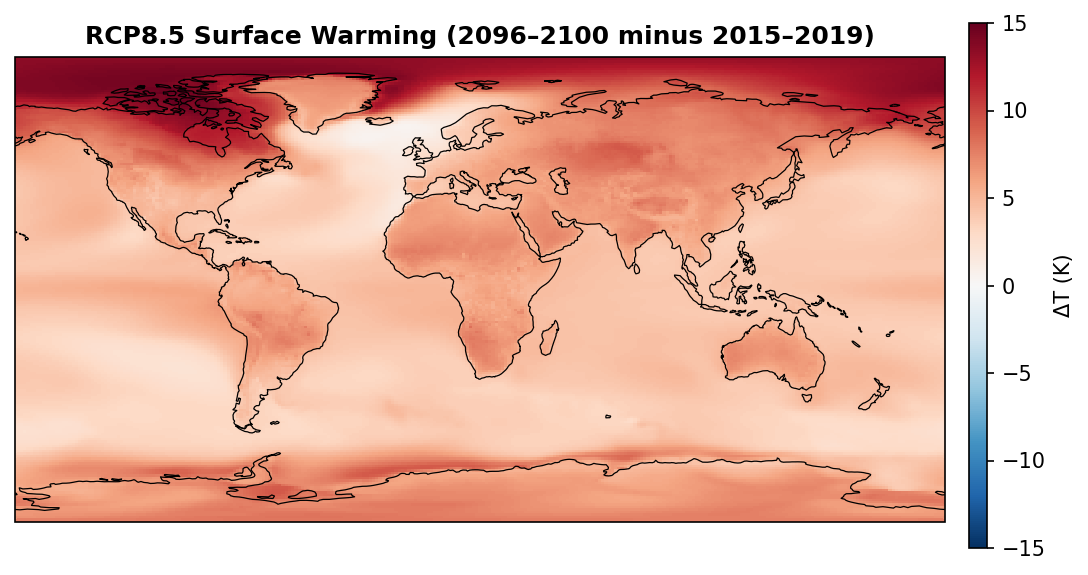

Plotting latitude vs warming...


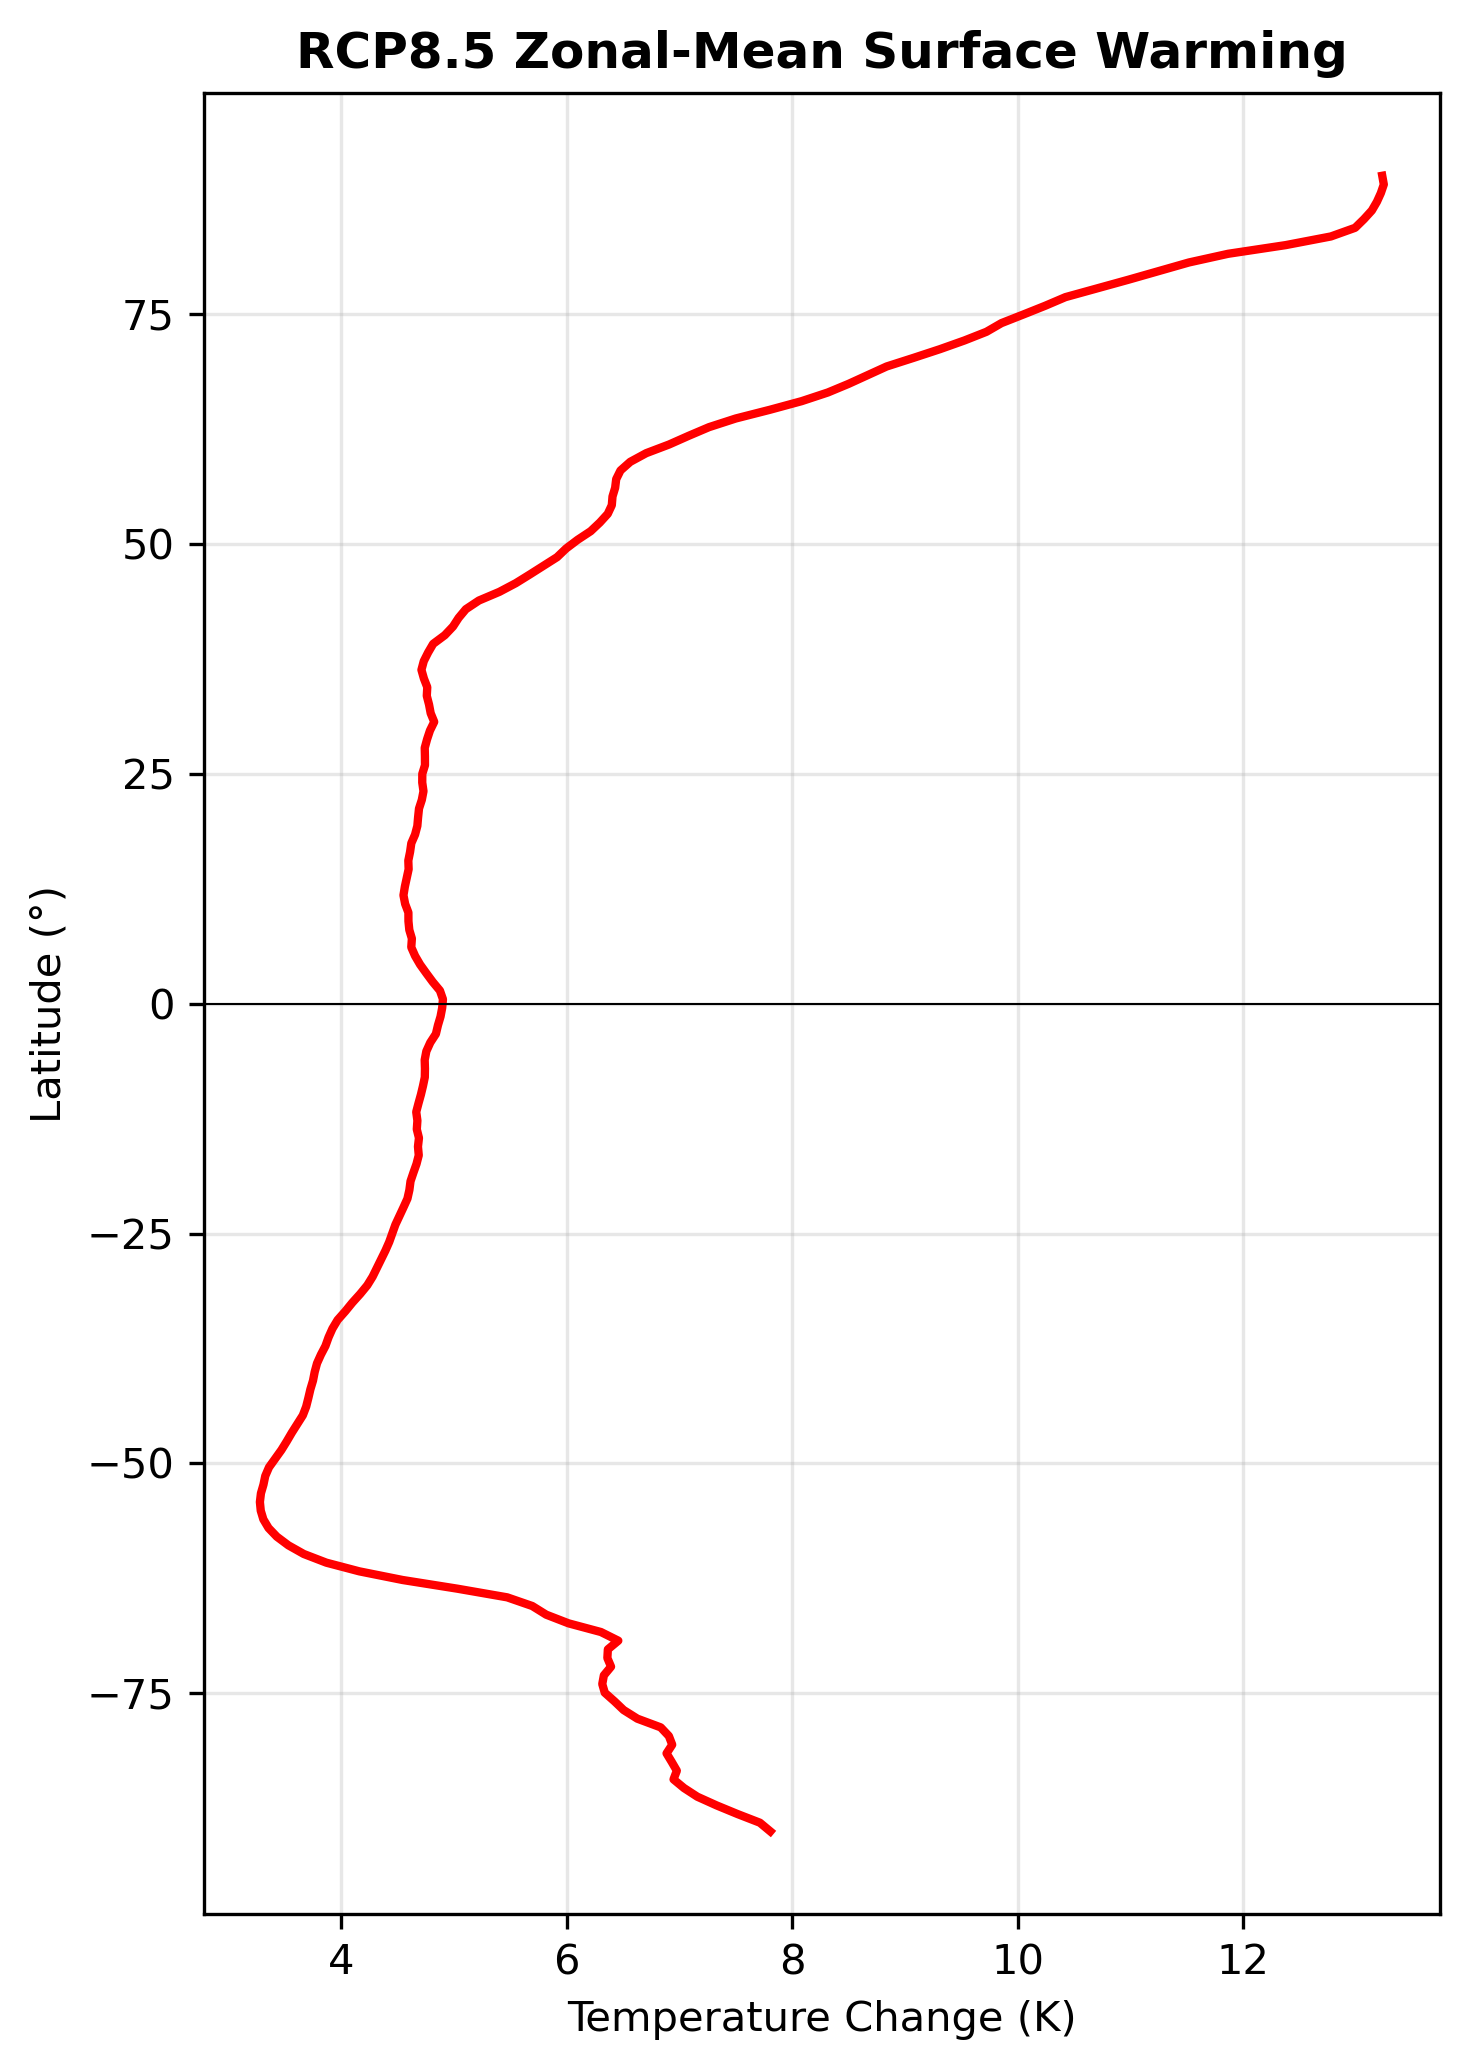

Plotting zonal-mean atmospheric temperature response...


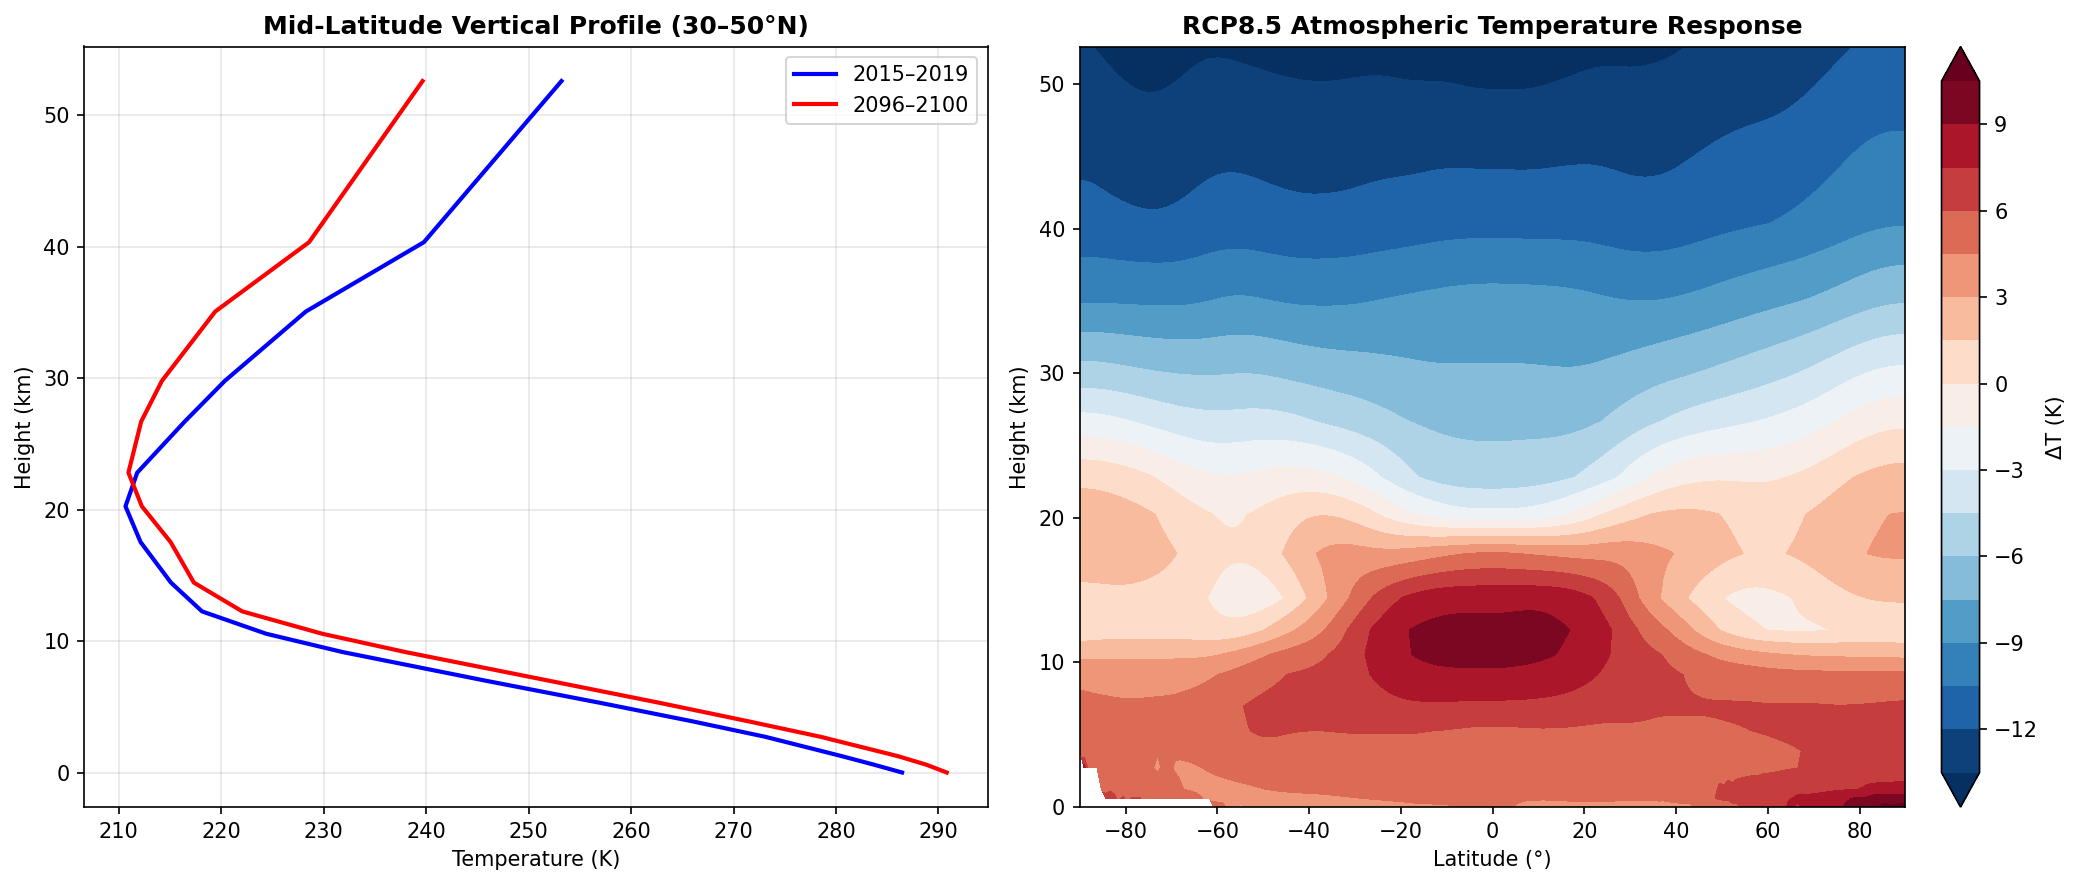

Plotting GMST PIcontrol vs observed to show hiatuses...


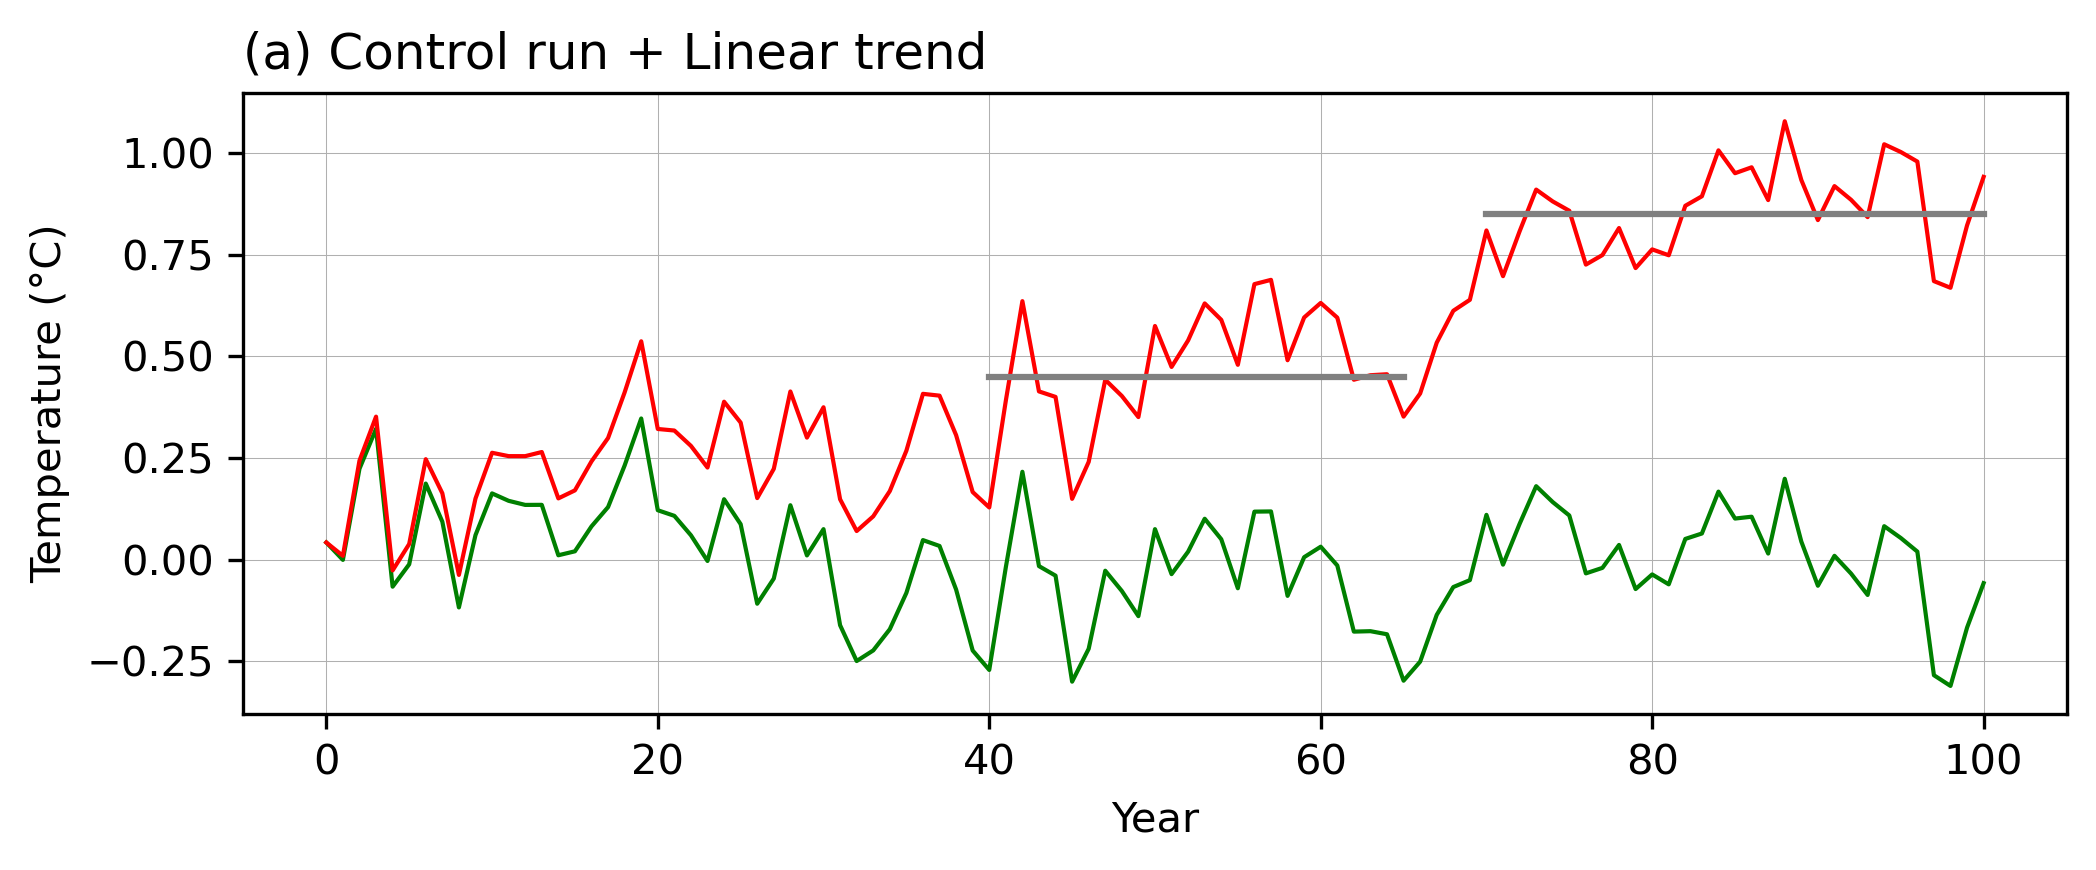


All book figures successfully created.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import cartopy.crs as ccrs
import cartopy.feature as cfeature

OUT_DIR = "./Output/to-pickle"

# =====================================================
# VERIFY FILES + AUTO-DETECT TEMPERATURE UNITS
# =====================================================
print("Verifying saved .npy files...\n")
npy_files = glob.glob(f"{OUT_DIR}/*.npy")

unit_system = None  # "C" or "K"

for f in sorted(npy_files):
    arr = np.load(f, allow_pickle=True)
    vmin, vmax = np.nanmin(arr), np.nanmax(arr)
    print(f"{f.split('/')[-1]} | shape: {arr.shape} | min: {vmin:.2f}, max: {vmax:.2f}")

    if unit_system is None and "SAT_map" in f:
        unit_system = "K" if vmax > 100 else "C"

if unit_system is None:
    unit_system = "C"

TEMP_LABEL = "°C" if unit_system == "C" else "K"
DELTA_LABEL = "ΔT (°C)" if unit_system == "C" else "ΔT (K)"

print(f"\nDetected temperature unit: {TEMP_LABEL}")

# =====================================================
# 1. GMST ANOMALY TIMESERIES (HOCKEY STICK)
# =====================================================
print("Plotting GMST anomaly timeseries...")

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

filename = "./Output/to-pickle/hockeystick_annual_temperature_anomaly_timeseries.npy"
T = np.load(filename, allow_pickle=True)
ax.plot(T[:,0], T[:,1], color="black", lw=2, label="Observed (GISS)")

colors = {"RCP26": "blue", "RCP45": "green", "RCP85": "red"}
for label in ["RCP26", "RCP45", "RCP85"]:
    data = np.load(f"{OUT_DIR}/{label}_GMST_annual_anomaly_timeseries.npy")
    ax.plot(data[:, 0], data[:, 1], lw=2, color=colors[label], label=label)

ax.set_xlabel("Year")
ax.set_ylabel(f"Temperature Anomaly ({TEMP_LABEL})")
ax.set_title("Global Mean Surface Temperature Anomaly", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Output/Figures/Fig_GMST_hockey_stick.png", bbox_inches="tight")
plt.show()

# =====================================================
# COMMON MAP SETTINGS (EUROPE / AFRICA CENTERED)
# =====================================================
proj = ccrs.PlateCarree(central_longitude=20)
data_crs = ccrs.PlateCarree()

coastline_style = dict(edgecolor="black", linewidth=0.6)
land_outline = cfeature.LAND.with_scale("110m")

# =====================================================
# 2. RCP8.5 SAT MAPS (FIRST vs LAST 5 YEARS)
# =====================================================
print("Plotting RCP8.5 SAT maps...")

tas_early = np.load(f"{OUT_DIR}/RCP85_SAT_map_first_5yr.npy")
tas_late  = np.load(f"{OUT_DIR}/RCP85_SAT_map_last_5yr.npy")
lat = np.load(f"{OUT_DIR}/RCP85_SAT_map_lat.npy")
lon = np.load(f"{OUT_DIR}/RCP85_SAT_map_lon.npy")
Lon, Lat = np.meshgrid(lon, lat)

vmin, vmax = (-30, 35) if unit_system == "C" else (240, 310)

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), dpi=150,
    subplot_kw={"projection": proj}
)

for ax, field, title in zip(
    axes,
    [tas_early, tas_late],
    ["RCP8.5 SAT (2015–2019)", "RCP8.5 SAT (2096–2100)"]
):
    cf = ax.pcolormesh(Lon, Lat, field, cmap="viridis",
                       vmin=vmin, vmax=vmax, transform=data_crs)
    ax.add_feature(land_outline, facecolor="none", edgecolor="black", linewidth=0.4)
    ax.coastlines(**coastline_style)
    ax.set_title(title, fontweight="bold")

# Proper colorbar to the right of both maps
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='vertical')
cbar.set_label(f"Temperature ({TEMP_LABEL})")

#plt.tight_layout(rect=[0,0,0.92,1])  # leave space for the colorbar
plt.savefig("Output/Figures/Fig_RCP85_SAT_maps.png", bbox_inches="tight")
plt.show()

# =====================================================
# 3. RCP8.5 SAT WARMING MAP
# =====================================================
print("Plotting RCP8.5 SAT warming map...")

delta_tas = tas_late - tas_early

fig = plt.figure(figsize=(8, 5), dpi=150)
ax = plt.axes(projection=proj)

cf = ax.pcolormesh(
    Lon, Lat, delta_tas,
    cmap="RdBu_r",
    vmin=-15, vmax=15,
    transform=data_crs
)

ax.add_feature(land_outline, facecolor="none", edgecolor="black", linewidth=0.4)
ax.coastlines(**coastline_style)

ax.set_title(
    "RCP8.5 Surface Warming (2096–2100 minus 2015–2019)",
    fontweight="bold"
)

# Add colorbar outside the map
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='vertical')
cbar.set_label(DELTA_LABEL)

#plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig("Output/Figures/Fig_RCP85_SAT_warming.png", bbox_inches="tight")
plt.show()

# =====================================================
# 4. RCP8.5 LATITUDE vs WARMING
# =====================================================
print("Plotting latitude vs warming...")

lat_warming = delta_tas.mean(axis=1)

fig, ax = plt.subplots(figsize=(5, 7), dpi=300)
ax.plot(lat_warming, lat, color="red", lw=2)
ax.axhline(0, color="black", lw=0.5)

ax.set_ylabel("Latitude (°)")
ax.set_xlabel(f"Temperature Change ({TEMP_LABEL})")
ax.set_title("RCP8.5 Zonal-Mean Surface Warming", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Output/Figures/Fig_RCP85_latitude_warming.png", bbox_inches="tight")
plt.show()

# =====================================================
# 5. ZONAL-MEAN ATMOSPHERIC TEMPERATURE RESPONSE
# =====================================================
print("Plotting zonal-mean atmospheric temperature response...")

ta_2010 = np.load(f"{OUT_DIR}/RCP85_zonally_avg_T_2010.npy")
ta_2100 = np.load(f"{OUT_DIR}/RCP85_zonally_avg_T_2100.npy")
lat = np.load(f"{OUT_DIR}/RCP85_zonally_avg_T_lat.npy")
vertical = np.load(f"{OUT_DIR}/RCP85_zonally_avg_T_height.npy")

lat_mask = (lat >= 30) & (lat <= 50)
ta_2010_mid = ta_2010[:, lat_mask].mean(axis=1)
ta_2100_mid = ta_2100[:, lat_mask].mean(axis=1)
delta_T = ta_2100 - ta_2010

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# Left panel: vertical profiles
axes[0].plot(ta_2010_mid, vertical, lw=2, color='blue', label="2015–2019")
axes[0].plot(ta_2100_mid, vertical, lw=2, color='red', label="2096–2100")
axes[0].set_xlabel(f"Temperature ({TEMP_LABEL})")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Mid-Latitude Vertical Profile (30–50°N)", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right panel: latitude–height response
cf = axes[1].contourf(lat, vertical, delta_T, levels=21, cmap="RdBu_r", extend="both")
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("Height (km)")
axes[1].set_title("RCP8.5 Atmospheric Temperature Response", fontweight="bold")

# Colorbar for right panel
cbar = fig.colorbar(cf, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label(DELTA_LABEL)

plt.tight_layout()
plt.savefig("Output/Figures/Fig_RCP85_atmospheric_response.png", bbox_inches="tight")
plt.show()


# =====================================================
# 6. GMST PIcontrol vs observed to show hiatuses
# =====================================================
print("Plotting GMST PIcontrol vs observed to show hiatuses...")
fig = plt.figure(figsize=(7,3),dpi=300)

PIcontrol_GMST=np.load("Output/PIcontrol_GMST_annual_anomaly_timeseries_temporary.npy")

year_start=200
years = PIcontrol_GMST[:,0]
mask=np.logical_and(years>=year_start,years<=year_start+100)
control_series = PIcontrol_GMST[mask,1]
control_series = control_series - np.mean(control_series)
control_years = PIcontrol_GMST[mask,0]
control_years = control_years-control_years[0]

# save final PIcontrol for students after selecting an appropriate start year:
control=np.column_stack((control_years, control_series))
PIcontrol_GMST = \
  np.save("Output/to-pickle/PIcontrol_GMST_annual_anomaly_timeseries.npy",control)

# The time axis for control time series:
# generate a linear trend based on the range
control_linear = control_years*.01
# combine the trend and the series
series_with_trend = control_linear + control_series

# --------------------------------------------------------------
# plot the control and control plus linear trend:
# --------------------------------------------------------------
hiatus_values=[[0.45,0.45],[0.85, 0.85]]
hiatus_years=[[40,65],[70,100]]

plt.plot(control_years, control_series,color="g",linewidth=1)
plt.plot(control_years, series_with_trend,color="r",linewidth=1)
for i in range(len(hiatus_values)):
    plt.plot(hiatus_years[i],hiatus_values[i],color="grey")

plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.title("(a) Control run + Linear trend",loc="left")
# plt.xlim(0,100)
# plt.ylim(0.0,2)
plt.grid(lw=0.25)
plt.tight_layout()
plt.savefig("Output/Figures/Fig_RCP85_atmospheric_response.png", bbox_inches="tight")
plt.show()


print("\nAll book figures successfully created.")